# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv") #completa el código
usage = pd.read_csv("/datasets/usage.csv") #completa el código

In [3]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print()
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).

**Hint:**
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Conclusiones Valores Nulos**

**Dataset plans:** 

No tiene valores faltantes; por lo tanto, no requiere intervención.

**Dataset users:**

* `city` Tiene 469 valores faltantes, que representa un 11.7%. Se va a investigar para definir si se imputan o se dejan como nulos.
* `churn_date` Tiene 3534 valores faltantes, que representa un 88.3%, los cuales se procede a eliminar.
    
**Dataset usage:**

* `date` Tiene 50 valores faltantes, que representan un 0.125%; por lo tanto, es un caso simple para imputación o para dejar como nulos. 
* `duration` Tiene 22076 valores faltantes, que representan un 55.1%. Se va a investigar para definir si se imputan o se dejan como nulos.
* `length` Tiene 17896 valores faltantes, que representa un 44.7%. Se va a investigar para definir si se imputan o se dejan como nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` presenta un comportamiento normal, con valores secuenciales que van desde un mínimo de 10000 hasta un máximo de 13999, esperados para un identificador único.
- La columna `age` presenta un valor inválido, ya que su valor minimo es **-999**; esto indica la presencia de datos erróneos. 

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` presentan un comportamiento normal y esperado para variables de identificación.
- Las columnas `duration` y `length` registran valores mínimos de 0, lo que puede ser normal; sin embargo, llama la atención el valor máximo de `length` (1490), el cual podría indicar un outlier.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` cuenta con 3531 registros, entre los que destacan 7 ciudades únicas, siendo Bogotá la ciudad con mayor presencia (808 registros). No se observan anomalías a primera vista.
- La columna `plan` cuenta con 4000 registros de 2 tipos de planes, siendo el plan básico el que tiene mayor presencia con (2595 registros). No se observan anomalías a primera vista.

In [15]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` cuenta con 40000 registros divididos en 2 categorías, donde text (mensajes de texto) es la más predominante, registrando una frecuencia de 22092 eventos. No se observan anomalías.



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**Conclusiones de valores inválidos**

Se detectó un valor sentinel en el dataset users, especificamente en la columna `age`, donde el valor mínimo es **-999**; por lo tanto, se deben reemplazar estos valores por nulos e imputarlos con la mediana de la edad de los usuarios, para garantizar que no se afecten análisis estadísticos posteriores. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date` se identificó la presencia de **40 registros correspondientes al año 2026**. Dado que la restricción del dataset indica que los datos válidos solo abarcan hasta el año 2024, estos casos representan fechas imposibles o errores de registro.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, el 100% de los registros de consumo corresponden exclusivamente al año **2024**, por lo que basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Diagnóstico revisión de fechas**

En el dataset users, en la columna `reg_date`, se identificó la presencia de 40 registros correspondientes al año 2026, lo cual es imposible; se trata de años sin transcurrir, basados en que la información solo registra hasta el año 2024. Por lo tanto, esos valores (año 2026) deben ser eliminados del dataset.

En el dataset usage, en la columna `date`, todos los consumos corresponden única y exclusivamente al año 2024; el análisis se enfocará obligatoriamente en este periodo.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, None).astype('float64')
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.143750
std        17.799868
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NaT)

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).sum().sort_values()

type
call        0
text    22076
Name: duration, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum().sort_values()

type
text        0
call    17896
Name: length, dtype: int64

En el dataset usage, los datos de las columnas `duration` y `length` son de tipo MAR (Missing at Random), ya que su ausencia sigue un patrón externo; la falta de datos depende completamente de la columna `type`. Por lo tanto, se deben dejar como nulos. No tendría sentido intentar imputar estos valores, ya que introduciría ruido y distorsionaría un análisis estadístico posterior.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'duration']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes', 'is_call': 'cant_llamadas', 'duration': 'cant_minutos_llamada'})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_numericas].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
distribucion_plan = user_profile['plan'].value_counts(normalize=True) * 100
print(distribucion_plan)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

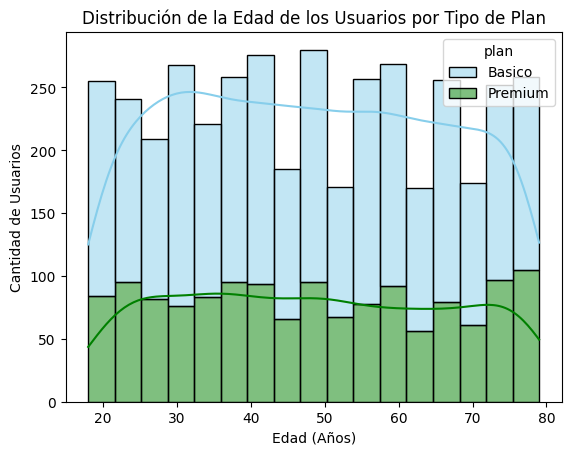

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True, multiple='stack')
plt.title('Distribución de la Edad de los Usuarios por Tipo de Plan')
plt.xlabel('Edad (Años)')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 

- El plan básico predomina en todos los rangos de edad con un volumen mayor que el plan premium.
- La edad no es un factor determinante para que un usuario decida contratar el plan premium o básico.
- Distribución simétrica (normal).

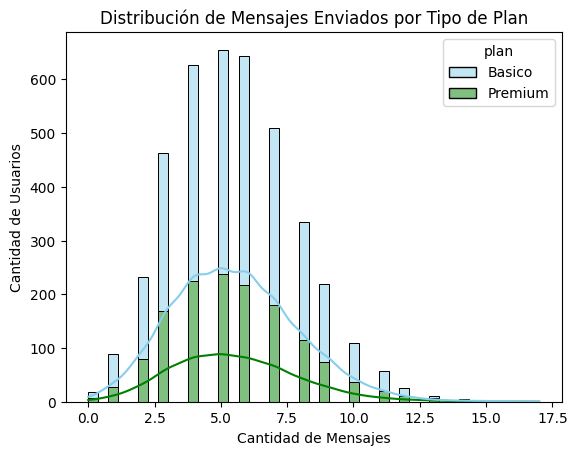

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True, multiple='stack')
plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:

- Hay una clara concentración de usuarios que envían entre 3 y 7 mensajes sin importar el plan.
- Los clientes existen en proporciones similares en ambas modalidades de contratación.
- Distribución sesgada a la derecha.

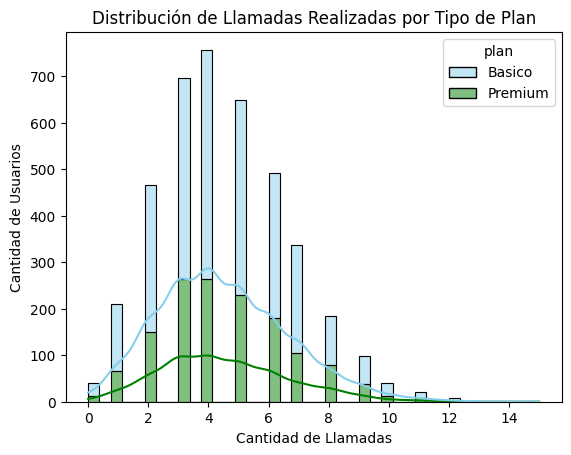

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True, multiple='stack')
plt.title('Distribución de Llamadas Realizadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 

- La gran mayoría de los usuarios hace un uso moderado del servicio de llamadas, concentrándose fuertemente entre 2 y 6 llamadas.
- El plan contratado no altera de manera drástica la cantidad de llamadas que realiza un usuario.
- El plan Básico duplica en volumen al plan Premium en cada una de las barras individuales.
- Distribución sesgada a la derecha.

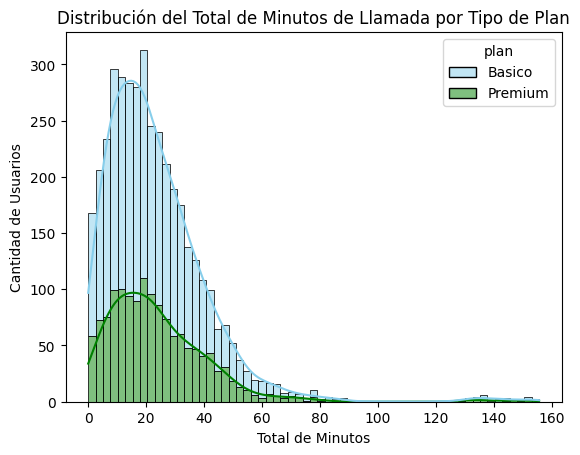

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True, multiple='stack')
plt.title('Distribución del Total de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 

- Al igual que con el conteo de llamadas y mensajes, el usuario promedio del plan Premium no habla significativamente más tiempo que el usuario promedio del plan Básico.
- Se observan valores atípicos (outliers) entre los 130 y 160 minutos, donde un pequeño grupo de usuarios genera consumos de voz extremadamente altos.
- Distribución fuertemente Sesgada a la Derecha.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

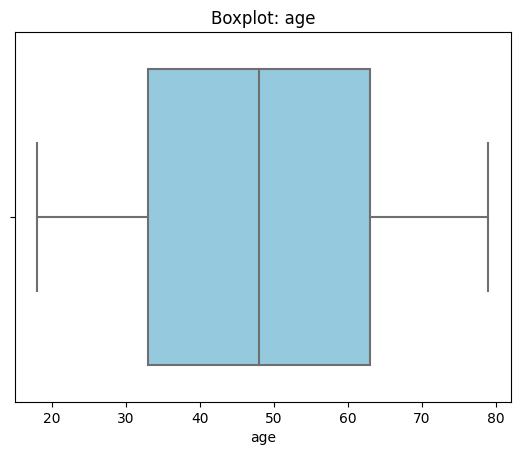

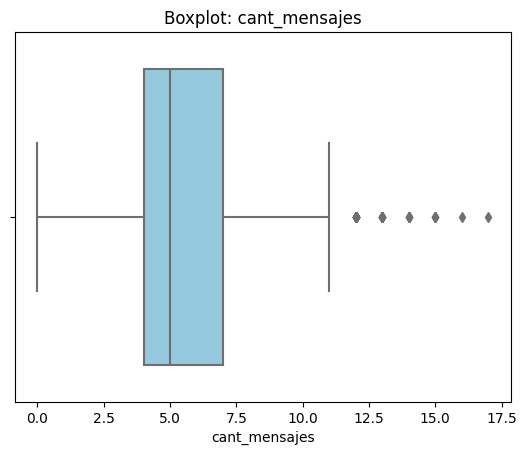

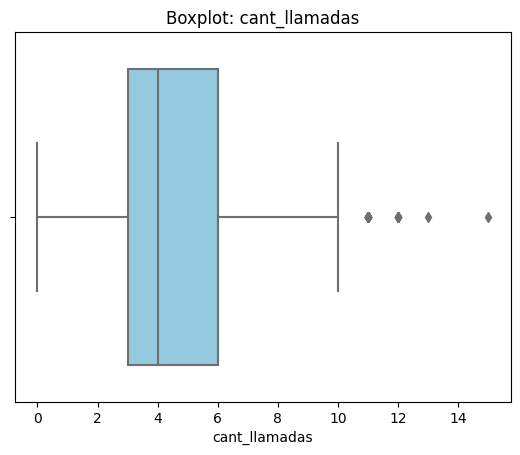

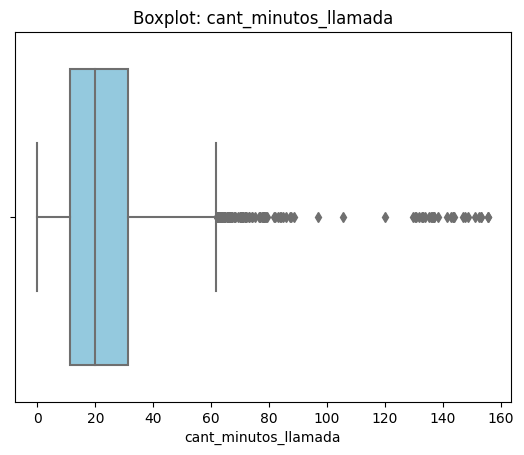

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()
    

💡Insights: 
- age: No presenta outliers.
- cant_mensajes: Presenta outliers.
- cant_llamadas: Presenta outliers.
- cant_minutos_llamada: Presenta outliers.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + (1.5 * IQR)
   
    print(f"Columna: {col}")
    print(f"Q1: {Q1:}")
    print(f"Q3: {Q3:}")
    print(f"IQR: {IQR:}")
    print(f"Límite Superior de tolerancia: {limite_superior:}")
    print()
    

Columna: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite Superior de tolerancia: 11.5

Columna: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite Superior de tolerancia: 10.5

Columna: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite Superior de tolerancia: 61.8575



In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

- cant_mensajes: Mantener los outliers (Keep). Los valores que superan el límite de tolerancia (11.5) son muy leves (máximo de 17 mensajes). Representan variaciones normales del día a día de un usuario común, no errores de medición.
- cant_llamadas: Mantener los outliers (Keep). Al igual que los mensajes, el exceso sobre el límite (10.5) es mínimo, alcanzando un máximo real de 15 llamadas. Son comportamientos completamente factibles dentro del uso habitual del servicio.
- cant_minutos_llamada: Mantener los outliers (Keep). Aunque el valor máximo (155.69 minutos) supera por mucho el límite tolerado (61.85), se trata de un comportamiento real, posiblemente clientes corporativos de alto valor. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso

def clasificar_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if llamadas < 5:
       if mensajes < 5:
            return 'Bajo uso'
       elif mensajes < 10:
            return 'Uso medio'
       else:
            return 'Alto uso'
    elif llamadas < 10:
        if mensajes < 10:
            return 'Uso medio'
        else:
            return 'Alto uso'
    else:
        return 'Alto uso'
            
user_profile["grupo_uso"] = user_profile.apply(clasificar_uso, axis=1) 


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
def clasificar_edad(row):
    edad = row['age']
   
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
     
user_profile["grupo_edad"] = user_profile.apply(clasificar_edad, axis=1) 

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

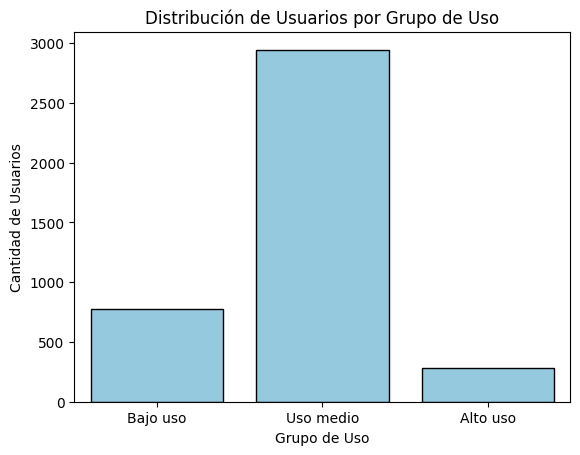

In [41]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', color='skyblue', edgecolor='black', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

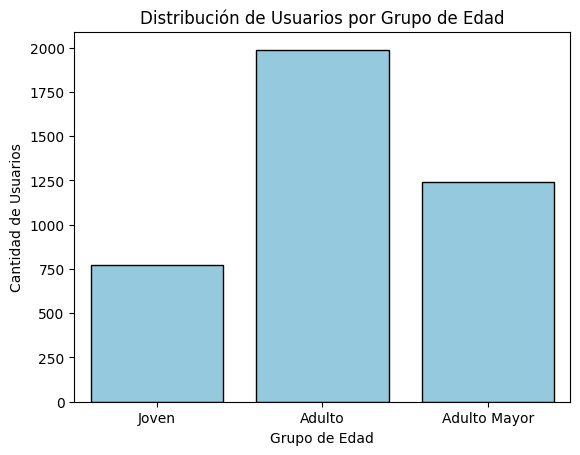

In [42]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', color='skyblue', edgecolor='black', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Al iniciar el proyecto se exploraron los diferentes dataset, se detectaron diferentes tipos de errores como valores nulos, valores invalidos, sentinels, los cuales fueron tratados y corregidos para evitar cualquier tipo de sesgo en el análisis comercial.

**Valores Nulos:** 

- En la columna `city` se detectaron 469 valores faltantes un (11.7%) de los datos, los cuales fueron investigados y finalmente se dejaron como nulos.
- En la columna `churn_date` se detecto un alto número de nulos (3534) representando un 88.3 % de los datos, fueron omitidos del analisis.
- En la columna `date` se detectaron 50 valores nulos un (0.125%) de los datos, por su bajo porcentaje se determino como caso simple que no afectaba en el analisis.
- En las columnas `duration` y `length` se detectaron un 55.1% y 44.7% de los datos faltantes, al realizar la investigación se detecto que son MAR, la falta de datos dependían completamente de la columna `type`. Por lo tanto se dejaron como nulos.

**Valores invalidos y sentinels**

- En `age` se identificaron registros con el valor sentinel **-999**. Tras enmascararlos, se determinó imputar los valores faltantes mediante la mediana para estabilizar las métricas.
- En la columna `city` se hallaron registros con el valor indeterminado **"?"** fueron estandarizados bajo la etiqueta "NaN" para mantener la integridad del volumen total de datos sin inventar información demográfica.
- En la columna `reg_data` se detectó un error que registraba 40 fechas imposibles en el futuro (año 2026). Dado que el dataset solo cubre actividad real hasta 2024, estas anomalías fueron neutralizadas como valores nulos (NaT) para evitar distorsiones en las métricas de antigüedad de clientes.

🔍 **Segmentos por Edad**

La población se distribuyó en tres grandes bloques biológicos para entender el impacto generacional: Joven (menor a 30 años), Adulto (menor a 60 años) y Adulto Mayor (superior a 60 años).

- La gráfica de distribución de frecuencias revela que el volumen de clientes está fuertemente centralizado en el grupo de Adultos. Para el negocio, esto implica que la estabilidad financiera de ConnectaTel depende directamente de la retención de este bloque de edad.
- En los tres grupos de edad, el plan básico supera de manera uniforme al plan premium. Esto demuestra que la edad biológica no influye en la decisión de compra ni genera una inclinación hacia un plan específico. 

📊 **Segmentos por Nivel de Uso**

Para desarrollar el análisis se crearon tres grupos de uso, clasificados en bajo uso, uso medio y alto uso, logrando concluir: 

- Uso medio es el segmento mayoritario, agrupa a los clientes que mantienen un consumo moderado y equilibrado (valores entre 5 y 9 unidades) tanto en mensajes como llamadas.
- El plan básico supera cómodamente al plan premium en las tres categorías de uso. Esto demuestra que, sin importar si el cliente consume poco, medio o mucho, la gran mayoría prefiere mantenerse bajo la estructura tarifaria del plan económico.

➡️ Esto sugiere que al visualizar las distribuciones de ambas gráficas, se descubrió que los hábitos de consumo y la adopción de planes se mantienen en proporciones muy similares. La edad influye en el tamaño del grupo (hay más adultos en total), pero no cambia la tendencia de comportamiento: en todas las edades el plan Básico sigue siendo el dominante y las proporciones de uso se mantienen estables.

✨ **Segmentos mas valiosos para ConnectaTel**

Al cruzar las dimensiones demográficas y de consumo, se determina que el perfil de cliente más crítico para la estabilidad operativa y financiera de ConnectaTel es el de usuarios Adultos bajo el Plan Básico. Al ser el rango de edad más masivo y el plan más contratado, este segmento representa el núcleo del negocio. Cualquier estrategia de retención, mejora de infraestructura o ajuste de tarifas debe diseñarse priorizando a este grupo, ya que cualquier variación en su fidelidad impactaría directamente al grueso de la facturación de la compañía.

⬆️ **Patrones de uso extremo (outliers) encontrados e implicaciones para el negocio**

Al aplicar el método del Rango Intercuartílico (IQR), se detectaron patrones de consumo extremo:

- En mensajes (máximo de 17 vs. límite de 11.5) y llamadas (máximo de 15 vs. límite de 10.5) los outliers son leves.
- En minutos de llamada, el fenómeno es crítico: el límite de tolerancia matemática se fijó en 61.85 minutos, pero registramos usuarios con picos reales de hasta 155.69 minutos.

Implicación de negocio: Estos outliers nos ayudan a identificar clientes de alto valor o perfiles corporativos. Para el negocio, esto implica la necesidad de garantizar infraestructura técnica que soporte estas cargas de larga duración sin caídas de red, y la oportunidad de crear ofertas exclusivas para este tipo de para evitar que se vayan con la competencia.

💡 **Recomendaciones**

- Se recomienda a la empresa dejar de diseñar publicidad dividida por generaciones (ej: "planes exclusivos para jóvenes"). En su lugar, el marketing debe orientarse a campañas basadas en perfiles de comportamiento (ej: "Planes para los que hablan más de lo que escriben"), optimizando así el costo de adquisición de clientes.
- Fidelización del núcleo del negocio ("Adultos en Plan Básico") ya que este grupo es demasiado grande para arriesgarse a que migren a la competencia. Se deben implementar beneficios de lealtad pasivos que no afecten el costo del plan pero aumenten su satisfacción; tales como la acumulación de minutos no consumidos para el mes siguiente o priorización en la atención al cliente.
- Ejecutar una estrategia de actualización de plan dirigida a usuarios que pagan plan básico pero están dentro del grupo alto uso. Mediante notificaciones personalizadas en sus facturas o la app de la empresa, se les puede demostrar con sus propios consumos históricos que les conviene migrar al Plan Premium, ofreciéndoles beneficios comerciales como los primeros tres meses con descuento.
- Crear un nuevo Plan Corporativo basado en los outliers para aquel grupo de usuarios que realizan llamadas extensas de hasta 155.69 minutos. ConnectaTel debe capitalizar este patrón extremo creando un nuevo plan que ofrezca bolsas de minutos de larga duración o llamadas ilimitadas a un precio significativamente mayor. Esto permite capturar el valor de estos clientes de alto consumo, garantizando que paguen una tarifa justa por el desgaste que generan en la infraestructura de la red.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`